# 03. RUL Feature Engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
columns = ["engine_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 22)]
df_train = pd.read_csv("../data/train_FD001.txt", sep="\s+", header=None, names=columns)
useless = ["sensor_1", "sensor_10", "sensor_18", "sensor_19", "op_setting_3"]
df_train = df_train.drop(columns=useless)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\gajen\AppData\Local\Temp\ipykernel_30272\521850770.py:5: SyntaxWarning: invalid escape sequence '\s'
  df_train = pd.read_csv("../data/train_FD001.txt", sep="\s+", header=None, names=columns)


In [2]:
df_train["RUL"] = df_train.groupby("engine_id")["cycle"].transform("max") - df_train["cycle"]
df_train[["engine_id", "cycle", "RUL"]].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


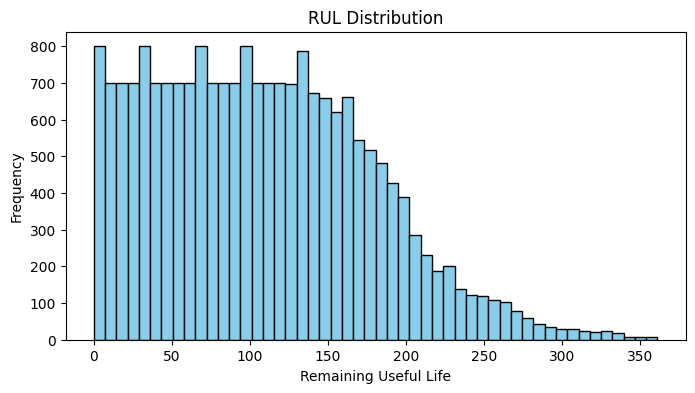

In [3]:
plt.figure(figsize=(8, 4))
plt.hist(df_train["RUL"], bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Remaining Useful Life")
plt.ylabel("Frequency")
plt.title("RUL Distribution")
plt.savefig("../figures/rul_distribution.png", bbox_inches="tight")
plt.show()

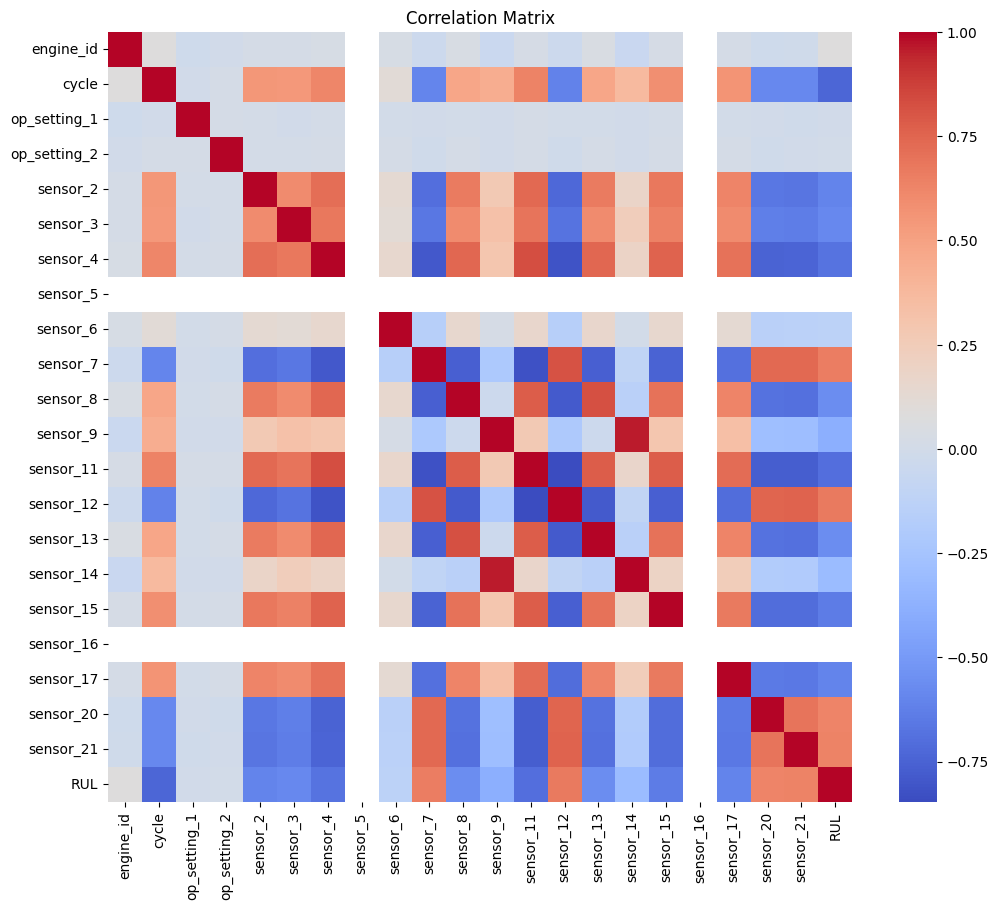

In [4]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_train.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("../figures/correlation_matrix.png", bbox_inches="tight")
plt.show()

In [5]:
def add_features(df, window=5):
    df_feat = df.copy()
    sensor_cols = [c for c in df.columns if "sensor" in c]
    for col in sensor_cols:
        df_feat[f"{col}_roll_mean"] = df_feat.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).mean())
        df_feat[f"{col}_roll_std"] = df_feat.groupby("engine_id")[col].transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df_feat
df_train_feat = add_features(df_train)
df_train_feat.to_csv("../data/train_engineered.csv", index=False)